# Análisis del Dato — Modelos Tabulares



Este notebook aborda el **modelado supervisado y no supervisado** de los tres datasets tabulares del TFG, tras la ingeniería del dato completada en los notebooks 01–03. Los datasets proceden de `data/processed/` y están **limpios, sin estandarizar** (la estandarización se aplica dentro del pipeline de sklearn para evitar data leakage).

| Dataset | Registros | Features | Target | Fuente |
|---------|-----------|----------|--------|--------|
| Heart Disease | 557 | 13 | `target` (0/1) | UCI – 4 hospitales |
| Breast Cancer | 569 | 23 | `diagnosis` (0/1) | UCI – Wisconsin FNA |
| Diabetes (Pima) | 768 | 13 | `Outcome` (0/1) | OpenML #37 – NIDDK |

---

## Configuración del entorno

In [1]:
import subprocess, sys                                                                                                                                                                                
for pkg in ['shap', 'xgboost']:                                                                                                                                                                       
    try:                                                                                                                                                                                              
      __import__(pkg)                                                                                                                                                                               
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    silhouette_score, adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import shap

# Paleta del TFG
TFG_COLORS = ['midnightblue', 'steelblue', 'darkorange', 'crimson', 'teal', 'forestgreen']
sns.set_palette(TFG_COLORS)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})

# Rutas
DATA_DIR = '../data/processed/'
REPORT_DIR = '../reports/'

# Contador global de figuras
FIG_NUM = 0

def next_fig():
    global FIG_NUM
    FIG_NUM += 1
    return FIG_NUM

print('Entorno configurado.')

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 24.0 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 80.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.8 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [shap]6/7 [shap]]te]



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Entorno configurado.


## Funciones auxiliares reutilizables

Centralizamos el código de entrenamiento, evaluación y visualización para evitar repetir ~300 líneas por dataset. Cada función está documentada para que sea comprensible en la lectura del TFG.

In [2]:
def get_models():
    """Devuelve los 7 modelos dentro de pipelines con StandardScaler."""
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, random_state=42))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', XGBClassifier(
                n_estimators=200, random_state=42, eval_metric='logloss',
                use_label_encoder=False
            ))
        ]),
        'Gradient Boosting': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
        ]),
        'AdaBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', AdaBoostClassifier(
                n_estimators=200, random_state=42,
            ))
        ]),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True, random_state=42))
        ]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=7))
        ]),
    }


def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    """Entrena los 7 modelos, recoge métricas en train y test, tiempos y CV.
    
    Devuelve:
        results_df: DataFrame con métricas por modelo.
        fitted_models: dict con los pipelines entrenados.
    """
    models = get_models()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    fitted = {}

    for name, pipe in models.items():
        # --- Entrenamiento ---
        t0 = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - t0

        fitted[name] = pipe

        # --- Predicciones ---
        y_pred_train = pipe.predict(X_train)
        y_pred_test = pipe.predict(X_test)
        y_proba_test = pipe.predict_proba(X_test)[:, 1]

        # --- Cross-validation 5-fold ---
        cv_scores = cross_validate(
            pipe, X_train, y_train, cv=cv,
            scoring=['accuracy', 'f1_macro', 'roc_auc'],
            return_train_score=False
        )

        rows.append({
            'Model': name,
            'Accuracy (test)': accuracy_score(y_test, y_pred_test),
            'F1 Macro (test)': f1_score(y_test, y_pred_test, average='macro'),
            'F1 Weighted (test)': f1_score(y_test, y_pred_test, average='weighted'),
            'Precision (test)': precision_score(y_test, y_pred_test, average='macro'),
            'Recall (test)': recall_score(y_test, y_pred_test, average='macro'),
            'AUC-ROC (test)': roc_auc_score(y_test, y_proba_test),
            'Accuracy (train)': accuracy_score(y_train, y_pred_train),
            'F1 Macro (train)': f1_score(y_train, y_pred_train, average='macro'),
            'CV Accuracy (mean)': cv_scores['test_accuracy'].mean(),
            'CV Accuracy (std)': cv_scores['test_accuracy'].std(),
            'CV F1 (mean)': cv_scores['test_f1_macro'].mean(),
            'CV F1 (std)': cv_scores['test_f1_macro'].std(),
            'CV AUC (mean)': cv_scores['test_roc_auc'].mean(),
            'CV AUC (std)': cv_scores['test_roc_auc'].std(),
            'Train time (s)': train_time,
        })

    results = pd.DataFrame(rows).sort_values('AUC-ROC (test)', ascending=False)
    return results, fitted


def plot_model_comparison(results, dataset_name, fig_dir):
    """Barplot comparativo de Accuracy, F1 Macro y AUC-ROC para los 7 modelos."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fnum = next_fig()
    metrics = ['Accuracy (test)', 'F1 Macro (test)', 'AUC-ROC (test)']
    titles = ['Accuracy', 'F1 Macro', 'AUC-ROC']

    for ax, metric, title in zip(axes, metrics, titles):
        data = results.sort_values(metric, ascending=True)
        bars = ax.barh(data['Model'], data[metric], color=TFG_COLORS[:len(data)])
        ax.set_xlim(max(0, data[metric].min() - 0.05), 1.0)
        ax.set_title(title)
        for bar, val in zip(bars, data[metric]):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

    fig.suptitle(f'Figura {fnum} — Comparativa de modelos: {dataset_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_model_comparison.png'),
                bbox_inches='tight', dpi=150)
    plt.show()


def plot_overfitting(results, dataset_name, fig_dir):
    """Compara train vs test F1 para detectar overfitting."""
    fnum = next_fig()
    data = results.sort_values('F1 Macro (test)', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = np.arange(len(data))
    w = 0.35

    ax.barh(y_pos - w/2, data['F1 Macro (train)'], w,
            label='Train', color='steelblue', alpha=0.85)
    ax.barh(y_pos + w/2, data['F1 Macro (test)'], w,
            label='Test', color='darkorange', alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(data['Model'])
    ax.set_xlabel('F1 Macro')
    ax.set_title(f'Figura {fnum} — Overfitting analysis: Train vs Test F1 ({dataset_name})')
    ax.legend()
    ax.set_xlim(0.5, 1.05)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_overfitting.png'),
                bbox_inches='tight', dpi=150)
    plt.show()


def plot_cv_with_ci(results, dataset_name, fig_dir):
    """Barplot de CV Accuracy con intervalos de confianza (±2 std ≈ 95%)."""
    fnum = next_fig()
    data = results.sort_values('CV Accuracy (mean)', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(data['Model'], data['CV Accuracy (mean)'],
            xerr=data['CV Accuracy (std)'] * 2,
            color='midnightblue', alpha=0.8, capsize=4)
    ax.set_xlabel('CV Accuracy (mean ± 2σ ≈ 95% CI)')
    ax.set_title(f'Figura {fnum} — Validación cruzada 5-fold: {dataset_name}')
    ax.set_xlim(max(0, data['CV Accuracy (mean)'].min() - 0.1), 1.0)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_cv_ci.png'),
                bbox_inches='tight', dpi=150)
    plt.show()


def plot_train_times(results, dataset_name, fig_dir):
    """Barplot de tiempos de entrenamiento."""
    fnum = next_fig()
    data = results.sort_values('Train time (s)', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(data['Model'], data['Train time (s)'], color='teal', alpha=0.85)
    ax.set_xlabel('Tiempo de entrenamiento (s)')
    ax.set_title(f'Figura {fnum} — Tiempos de entrenamiento: {dataset_name}')
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row['Train time (s)'] + 0.002, i, f"{row['Train time (s)']:.3f}s", va='center', fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_train_times.png'),
                bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(model, X_test, y_test, model_name, dataset_name, fig_dir):
    """Matriz de confusión del mejor modelo."""
    fnum = next_fig()
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negativo (0)', 'Positivo (1)'],
                yticklabels=['Negativo (0)', 'Positivo (1)'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'Figura {fnum} — Matriz de confusión: {model_name} ({dataset_name})')
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_confusion_matrix.png'),
                bbox_inches='tight', dpi=150)
    plt.show()

    print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))


def plot_roc_curve(model, X_test, y_test, model_name, dataset_name, fig_dir):
    """Curva ROC del mejor modelo."""
    fnum = next_fig()
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='crimson', lw=2, label=f'{model_name} (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Figura {fnum} — Curva ROC: {model_name} ({dataset_name})')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_roc_curve.png'),
                bbox_inches='tight', dpi=150)
    plt.show()


def plot_feature_importance(model, feature_names, model_name, dataset_name, fig_dir):                                                                                                                                                                                                                                 
    """Feature importance del mejor modelo (o del mejor tree-based si el ganador no lo tiene)."""                                                                                                                                                                                                                     
    clf = model.named_steps['clf']                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                        
    if not hasattr(clf, 'feature_importances_'):                                                                                                                                                                                                                                                                      
        print(f'{model_name} no tiene feature_importances_ nativo (es SVM/KNN/LR).')                                                                                                                                                                                                                                  
        print('Usa el mejor modelo basado en árboles para esta visualización.')                                                                                                                                                                                                                                       
        return None                                                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                                                                                        
    importances = clf.feature_importances_                                                                                                                                                                                                                                                                            
    idx = np.argsort(importances)                                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                                                                                        
    fnum = next_fig()
    fig, ax = plt.subplots(figsize=(10, 7))                                                                                                                                                                                                                                                                           
    ax.barh(np.array(feature_names)[idx], importances[idx], color='midnightblue', alpha=0.85)                                                                                                                                                                                                                       
    ax.set_xlabel('Importancia')                                                                                                                                                                                                                                                                                      
    ax.set_title(f'Figura {fnum} — Feature Importance: {model_name} ({dataset_name})')                                                                                                                                                                                                                                
    ax.grid(axis='x', alpha=0.3)                                                                                                                                                                                                                                                                                      
    plt.tight_layout()                                                                                                                                                                                                                                                                                                
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_feature_importance.png'),                                                                                                                                                                                                                                       
                bbox_inches='tight', dpi=150)
    plt.show()                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                                      
    return importances 


def run_unsupervised(X, y, feature_names, dataset_name, fig_dir):
    """PCA + K-Means: análisis no supervisado previo al modelado."""
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    # --- PCA: varianza explicada acumulada ---
    pca_full = PCA(random_state=42)
    pca_full.fit(X_sc)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    fnum = next_fig()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='midnightblue', lw=2)
    axes[0].axhline(y=0.95, color='crimson', ls='--', alpha=0.7, label='95% varianza')
    axes[0].set_xlabel('Nº de componentes')
    axes[0].set_ylabel('Varianza explicada acumulada')
    axes[0].set_title('Varianza explicada acumulada (PCA)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- PCA 2D coloreado por target ---
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X_sc)

    colors_target = ['steelblue', 'crimson']
    for label, color in zip([0, 1], colors_target):
        mask = y == label
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=color, alpha=0.5, s=30,
                       label=f'Clase {label}', edgecolor='white', lw=0.3)
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    axes[1].set_title('PCA 2D — coloreado por target')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(f'Figura {fnum} — PCA: {dataset_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum:02d}_pca.png'),
                bbox_inches='tight', dpi=150)
    plt.show()

    n_95 = np.argmax(cum_var >= 0.95) + 1
    print(f'Componentes necesarios para 95% de varianza: {n_95} de {X_sc.shape[1]}')
    print(f'PC1 + PC2 explican: {cum_var[1]:.1%} de la varianza total')

    # --- K-Means k=2 ---
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_sc)

    sil = silhouette_score(X_sc, clusters)
    ari = adjusted_rand_score(y, clusters)

    # Tabla de contingencia
    contingency = pd.crosstab(
        pd.Series(y.values, name='Clase real'),
        pd.Series(clusters, name='Cluster K-Means')
    )

    fnum2 = next_fig()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for cl, color in zip([0, 1], ['darkorange', 'teal']):
        mask = clusters == cl
        axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=color, alpha=0.5, s=30,
                       label=f'Cluster {cl}', edgecolor='white', lw=0.3)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].set_title('K-Means clusters (k=2)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Tabla de contingencia: Clusters vs Clases reales')

    fig.suptitle(f'Figura {fnum2} — K-Means: {dataset_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, f'fig{fnum2:02d}_kmeans.png'),
                bbox_inches='tight', dpi=150)
    plt.show()

    print(f'\nSilhouette Score: {sil:.3f}')
    print(f'Adjusted Rand Index (clusters vs target): {ari:.3f}')
    print(f'\nTabla de contingencia:\n{contingency}')

    return {'silhouette': sil, 'ari': ari, 'n_components_95': n_95}

---

# DATASET 1: Heart Disease

El dataset combina 4 hospitales (Cleveland, Hungarian, Switzerland, VA Long Beach) con 557 registros tras la limpieza. Target binario: 0 = sano, 1 = enfermedad cardíaca presente.

**Nota importante:** La columna `source` indica el hospital de origen y se usa solo para trazabilidad. Se **excluye** del modelado porque no es una feature clínica.

In [3]:
# --- Carga y preparación ---
df_heart = pd.read_csv(os.path.join(DATA_DIR, 'heart_disease_clean.csv'))
print(f'Shape: {df_heart.shape}')
print(f'Columnas: {list(df_heart.columns)}')
print(f'\nDistribución del target:\n{df_heart["target"].value_counts()}')

# Excluir 'source'
X_heart = df_heart.drop(columns=['target', 'source'])
y_heart = df_heart['target']
heart_features = list(X_heart.columns)
print(f'\nFeatures para modelado ({len(heart_features)}): {heart_features}')

Shape: (434, 15)
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'source', 'target']

Distribución del target:
target
1    247
0    187
Name: count, dtype: int64

Features para modelado (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


### 1.1 Análisis no supervisado (PCA + K-Means)

Antes de aplicar modelos supervisados, evaluamos si los datos tienen **estructura natural separable** con técnicas no supervisadas. Esto responde a la pregunta: *¿existe en los datos una agrupación inherente que coincida con la presencia/ausencia de enfermedad cardíaca?*

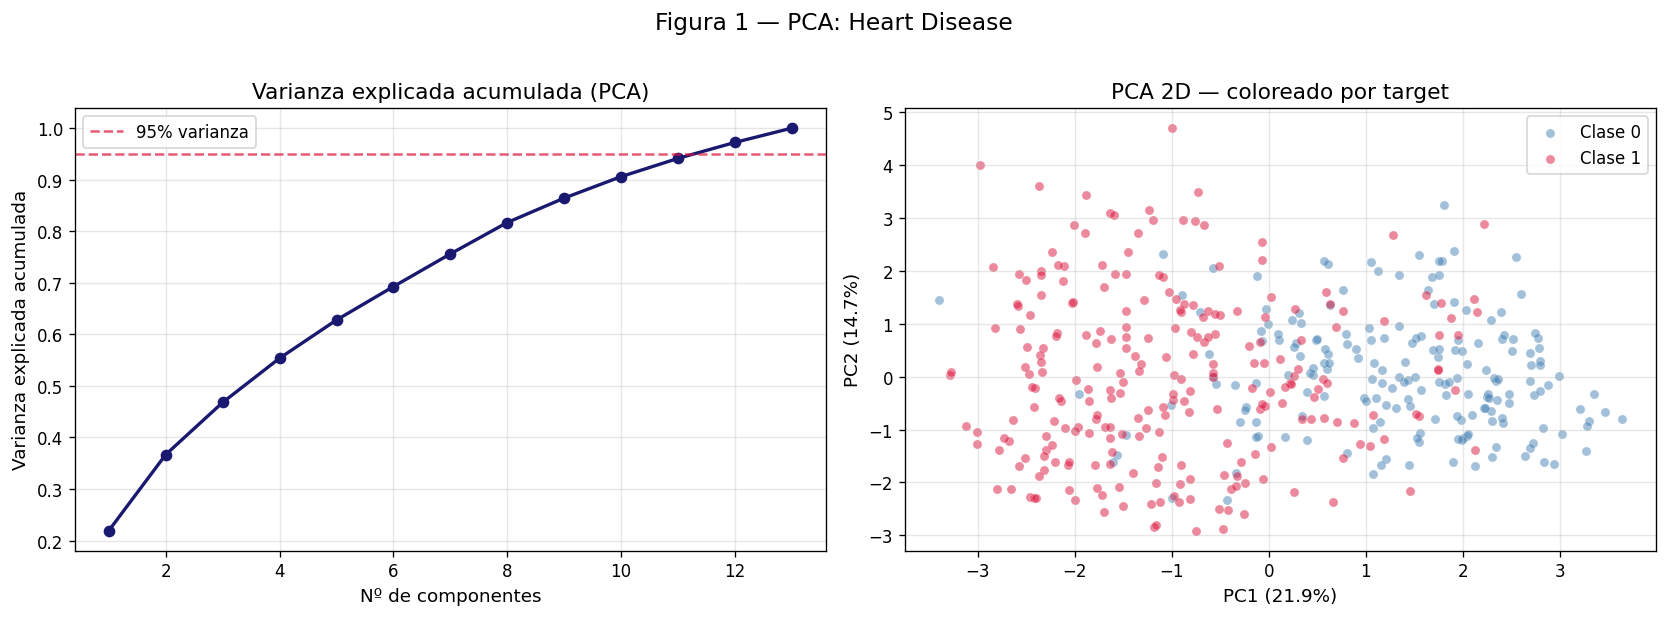

Componentes necesarios para 95% de varianza: 12 de 13
PC1 + PC2 explican: 36.7% de la varianza total


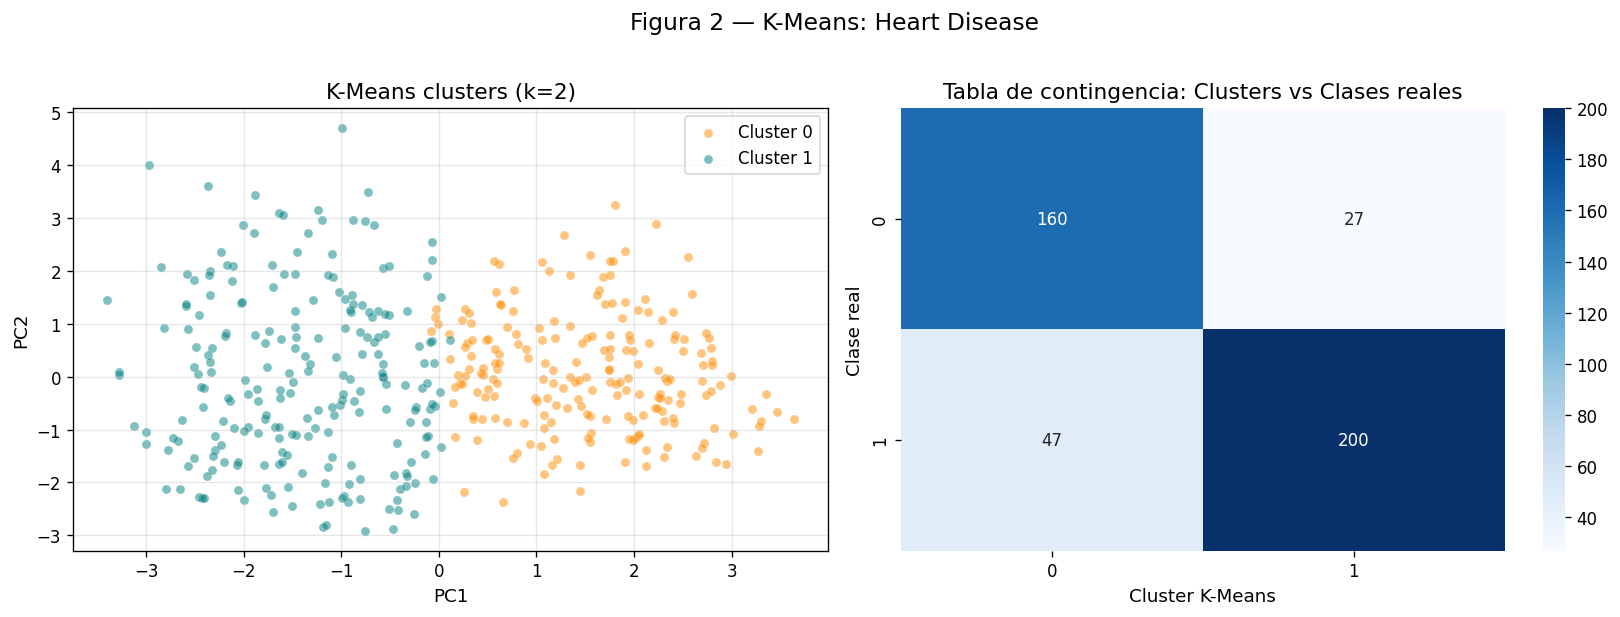


Silhouette Score: 0.158
Adjusted Rand Index (clusters vs target): 0.433

Tabla de contingencia:
Cluster K-Means    0    1
Clase real               
0                160   27
1                 47  200


In [4]:
heart_fig_dir = os.path.join(REPORT_DIR, 'figures_heart')
heart_unsup = run_unsupervised(X_heart, y_heart, heart_features, 'Heart Disease', heart_fig_dir)

### 1.2 Entrenamiento de los 7 modelos supervisados

In [5]:
# Split estratificado 80/20
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)
print(f'Train: {X_train_h.shape}, Test: {X_test_h.shape}')
print(f'Train target distribution:\n{y_train_h.value_counts(normalize=True).round(3)}')

Train: (347, 13), Test: (87, 13)
Train target distribution:
target
1    0.568
0    0.432
Name: proportion, dtype: float64


In [6]:
results_heart, fitted_heart = evaluate_models(
    X_train_h, X_test_h, y_train_h, y_test_h, 'Heart Disease'
)
results_heart.round(4)

,Model,Accuracy (test),F1 Macro (test),F1 Weighted (test),Precision (test),Recall (test),AUC-ROC (test),Accuracy (train),F1 Macro (train),CV Accuracy (mean),CV Accuracy (std),CV F1 (mean),CV F1 (std),CV AUC (mean),CV AUC (std),Train time (s)
5,SVM,0.8736,0.8679,0.8720,0.8804,0.8619,0.9449,0.9337,0.9326,0.8586,0.0340,0.8565,0.0354,0.9187,0.0272,0.0066
0,Logistic Regression,0.8736,0.8679,0.8720,0.8804,0.8619,0.9341,0.8646,0.8621,0.8387,0.0319,0.8358,0.0326,0.8932,0.0259,0.0079
1,Random Forest,0.8621,0.8552,0.8599,0.8713,0.8484,0.9295,1.0000,1.0000,0.8328,0.0435,0.8274,0.0485,0.9169,0.0311,0.0890
3,Gradient Boosting,0.8621,0.8578,0.8615,0.8613,0.8554,0.9276,1.0000,1.0000,0.8271,0.0483,0.8217,0.0527,0.9027,0.0297,0.0768
2,XGBoost,0.8621,0.8589,0.8621,0.8589,0.8589,0.9265,1.0000,1.0000,0.8185,0.0347,0.8136,0.0368,0.9039,0.0419,0.1918
4,AdaBoost,0.8736,0.8702,0.8733,0.8717,0.8689,0.9168,0.9049,0.9030,0.8472,0.0328,0.8446,0.0350,0.9176,0.0305,0.0810
6,KNN,0.8621,0.8552,0.8599,0.8713,0.8484,0.9141,0.8876,0.8859,0.8386,0.0385,0.8354,0.0402,0.9013,0.0386,0.0022


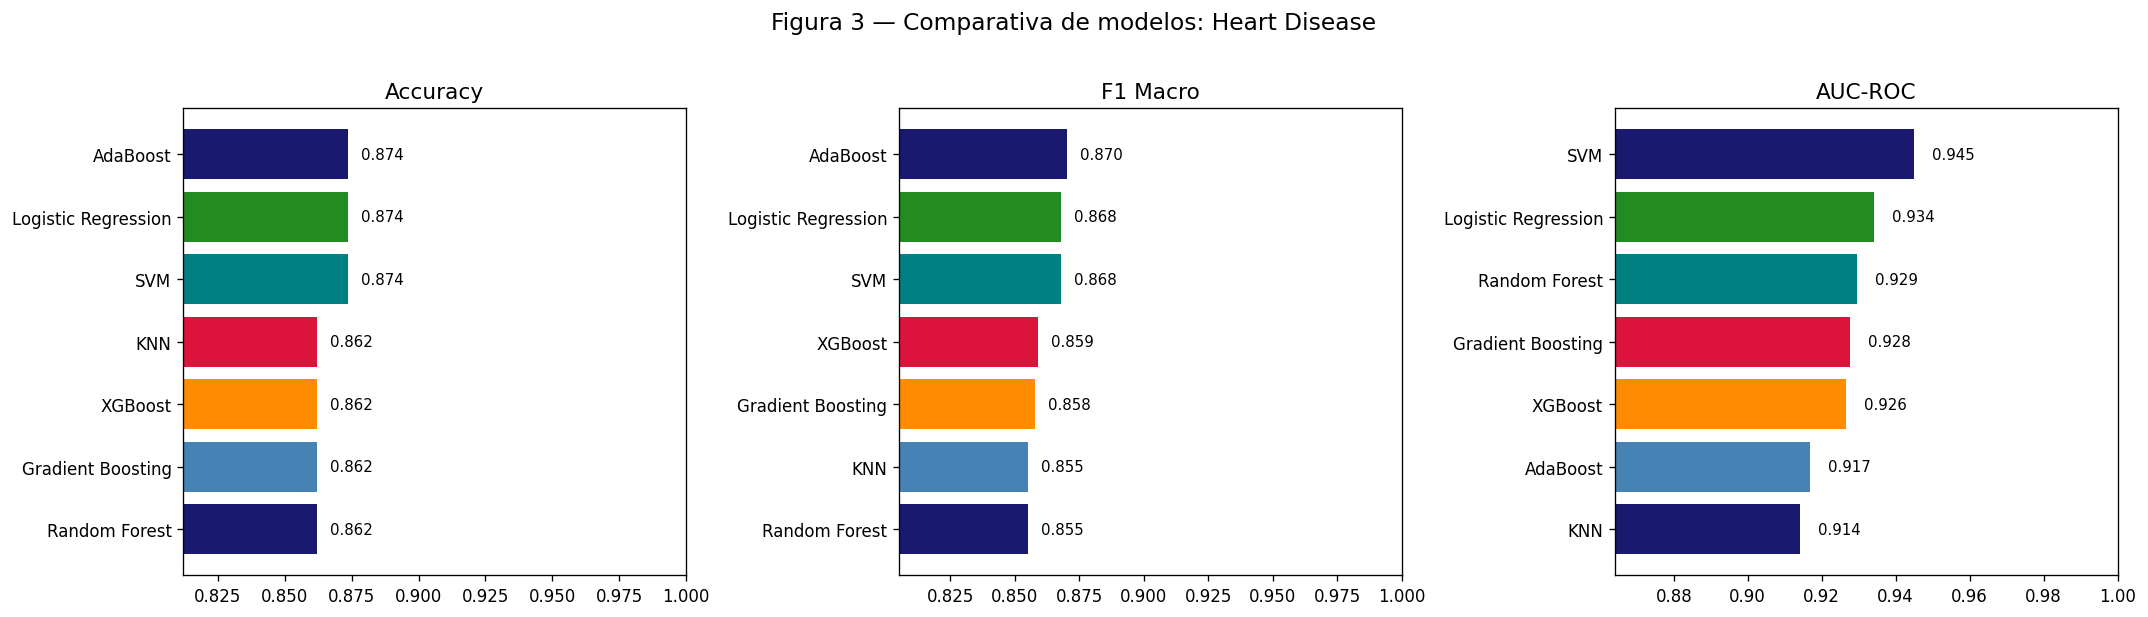

In [7]:
plot_model_comparison(results_heart, 'Heart Disease', heart_fig_dir)

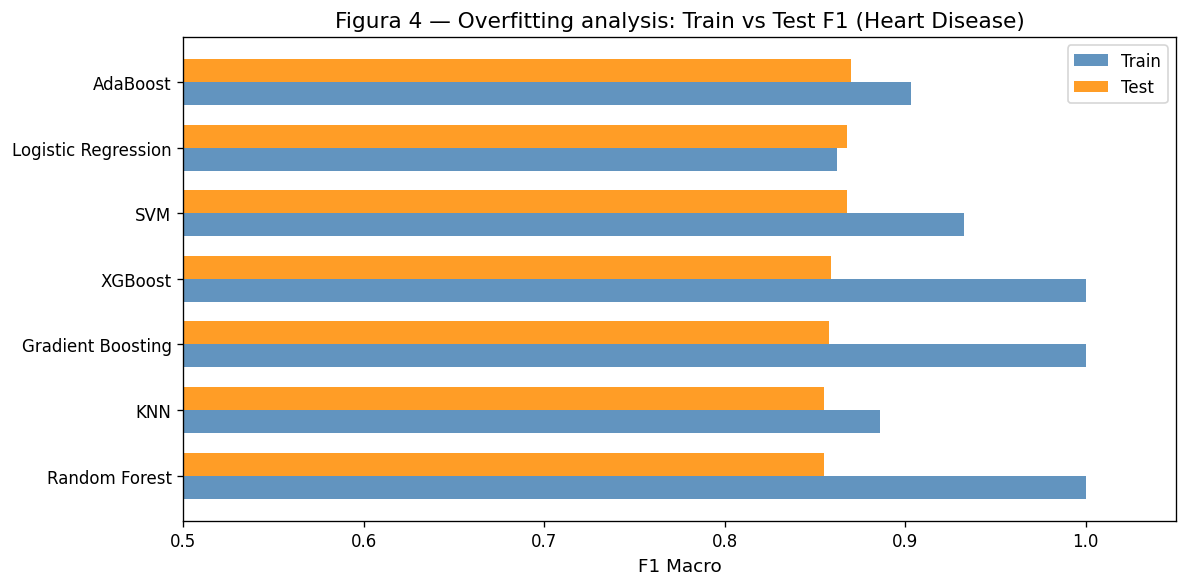

In [8]:
plot_overfitting(results_heart, 'Heart Disease', heart_fig_dir)

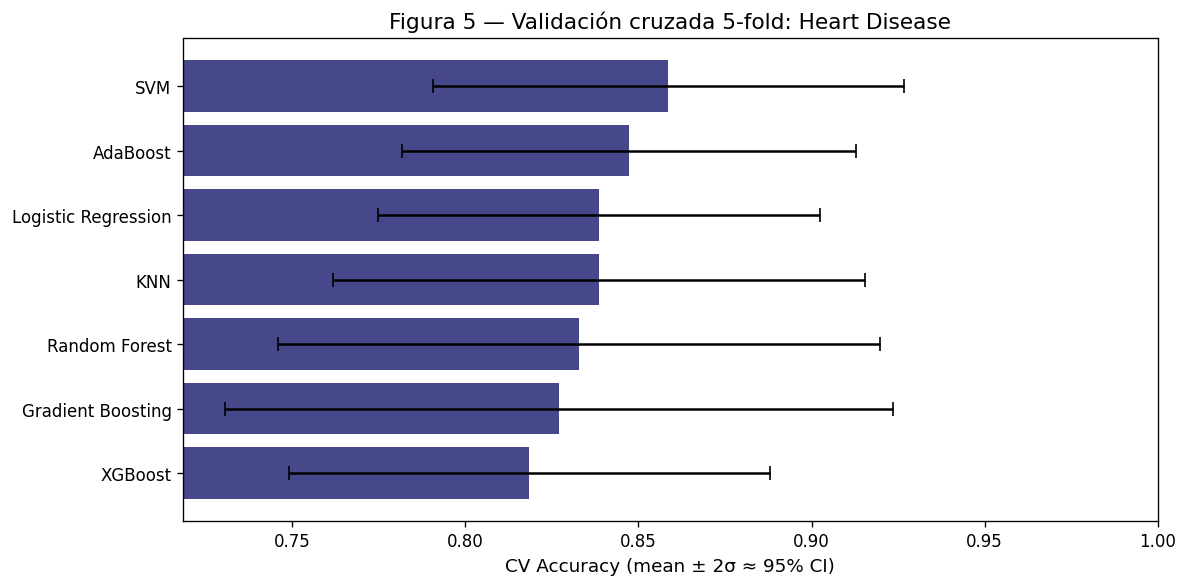

In [9]:
plot_cv_with_ci(results_heart, 'Heart Disease', heart_fig_dir)

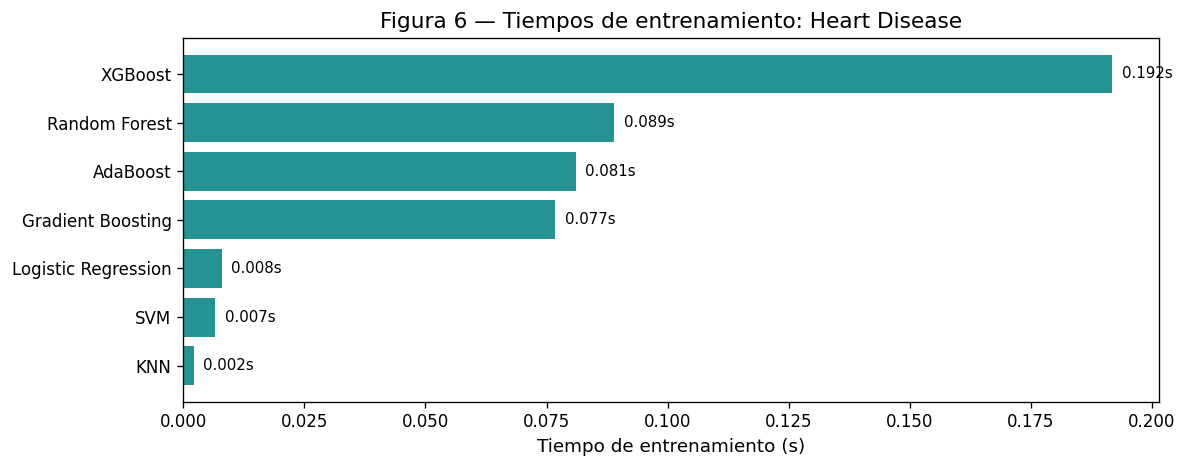

In [10]:
plot_train_times(results_heart, 'Heart Disease', heart_fig_dir)

### 1.3 Hyperparameter tuning (top 2-3 modelos)

In [11]:
# Seleccionamos los 3 mejores por AUC-ROC para tuning
top3_heart = results_heart.head(3)['Model'].tolist()
print(f'Top 3 modelos para tuning: {top3_heart}')

# Grids de hiperparámetros
param_grids = {
    'Random Forest': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [5, 10, 15, None],
        'clf__min_samples_split': [2, 5, 10],
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.1, 0.2],
        'clf__subsample': [0.8, 1.0],
    },
    'Gradient Boosting': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.1, 0.2],
    },
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear'],
    },
    'SVM': {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9, 11],
        'clf__weights': ['uniform', 'distance'],
    },
    'AdaBoost': {
        'clf__n_estimators': [50, 100, 200, 300],
        'clf__learning_rate': [0.01, 0.1, 0.5, 1.0],
    },
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_heart = {}

for model_name in top3_heart:
    if model_name not in param_grids:
        print(f'  No hay grid definido para {model_name}, se usa el modelo base.')
        tuned_heart[model_name] = fitted_heart[model_name]
        continue

    pipe = get_models()[model_name]
    grid = param_grids[model_name]
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)

    if n_combos > 50:
        search = RandomizedSearchCV(
            pipe, grid, n_iter=30, cv=cv_strat, scoring='roc_auc',
            random_state=42, n_jobs=-1, verbose=0
        )
    else:
        search = GridSearchCV(
            pipe, grid, cv=cv_strat, scoring='roc_auc', n_jobs=-1, verbose=0
        )

    print(f'\nTuning {model_name} ({n_combos} combinaciones)...')
    search.fit(X_train_h, y_train_h)
    tuned_heart[model_name] = search.best_estimator_
    print(f'  Mejor AUC-ROC CV: {search.best_score_:.4f}')
    print(f'  Mejores params: {search.best_params_}')

    # Evaluar en test
    y_pred = search.best_estimator_.predict(X_test_h)
    y_proba = search.best_estimator_.predict_proba(X_test_h)[:, 1]
    print(f'  Test AUC-ROC: {roc_auc_score(y_test_h, y_proba):.4f}')
    print(f'  Test F1 Macro: {f1_score(y_test_h, y_pred, average="macro"):.4f}')

Top 3 modelos para tuning: ['SVM', 'Logistic Regression', 'Random Forest']

Tuning SVM (12 combinaciones)...
  Mejor AUC-ROC CV: 0.9187
  Mejores params: {'clf__C': 1.0, 'clf__gamma': 'scale'}
  Test AUC-ROC: 0.9449
  Test F1 Macro: 0.8679

Tuning Logistic Regression (8 combinaciones)...
  Mejor AUC-ROC CV: 0.8967
  Mejores params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  Test AUC-ROC: 0.9351
  Test F1 Macro: 0.8824

Tuning Random Forest (36 combinaciones)...
  Mejor AUC-ROC CV: 0.9189
  Mejores params: {'clf__max_depth': 15, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
  Test AUC-ROC: 0.9324
  Test F1 Macro: 0.8552


In [12]:
# Identificar el mejor modelo final (el tuned con mejor AUC en test)
best_heart_name = max(
    tuned_heart,
    key=lambda n: roc_auc_score(y_test_h, tuned_heart[n].predict_proba(X_test_h)[:, 1])
)
best_heart = tuned_heart[best_heart_name]
print(f'\n>>> Mejor modelo Heart Disease: {best_heart_name}')


>>> Mejor modelo Heart Disease: SVM


### 1.4 Evaluación detallada del mejor modelo

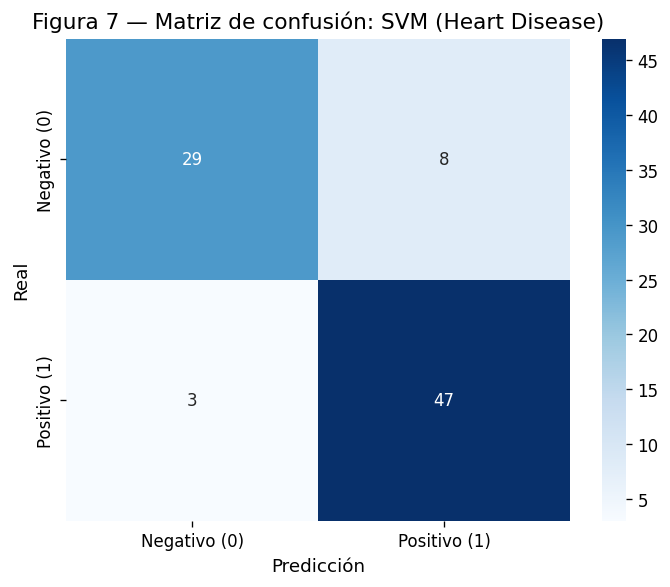

              precision    recall  f1-score   support

    Negativo       0.91      0.78      0.84        37
    Positivo       0.85      0.94      0.90        50

    accuracy                           0.87        87
   macro avg       0.88      0.86      0.87        87
weighted avg       0.88      0.87      0.87        87



In [13]:
plot_confusion_matrix(best_heart, X_test_h, y_test_h, best_heart_name, 'Heart Disease', heart_fig_dir)

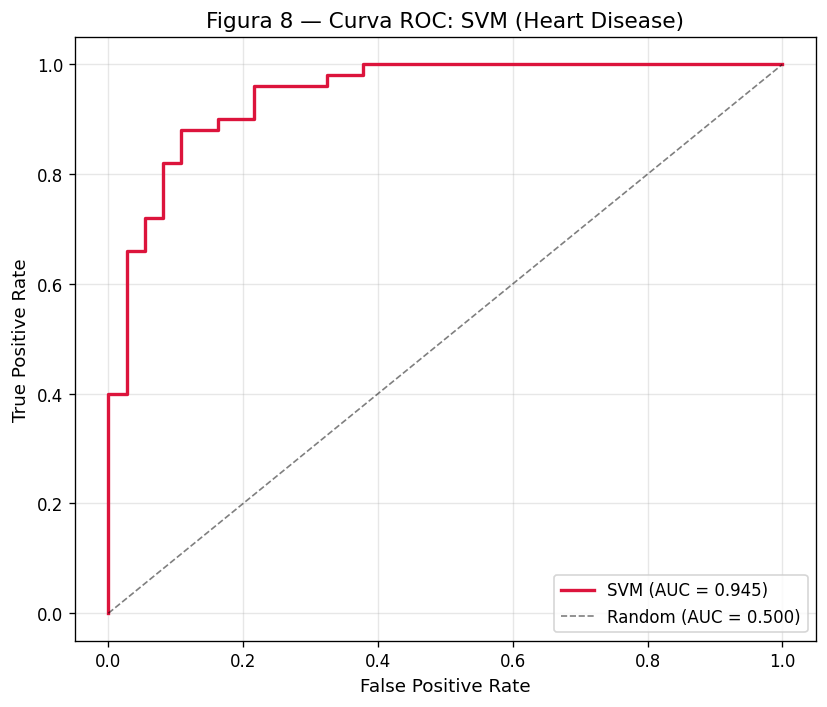

In [14]:
plot_roc_curve(best_heart, X_test_h, y_test_h, best_heart_name, 'Heart Disease', heart_fig_dir)

### 1.5 Explicabilidad — SHAP

Modelo usado para SHAP: Random Forest
(AUC-ROC test: 0.9295)
SHAP values shape: (87, 13)


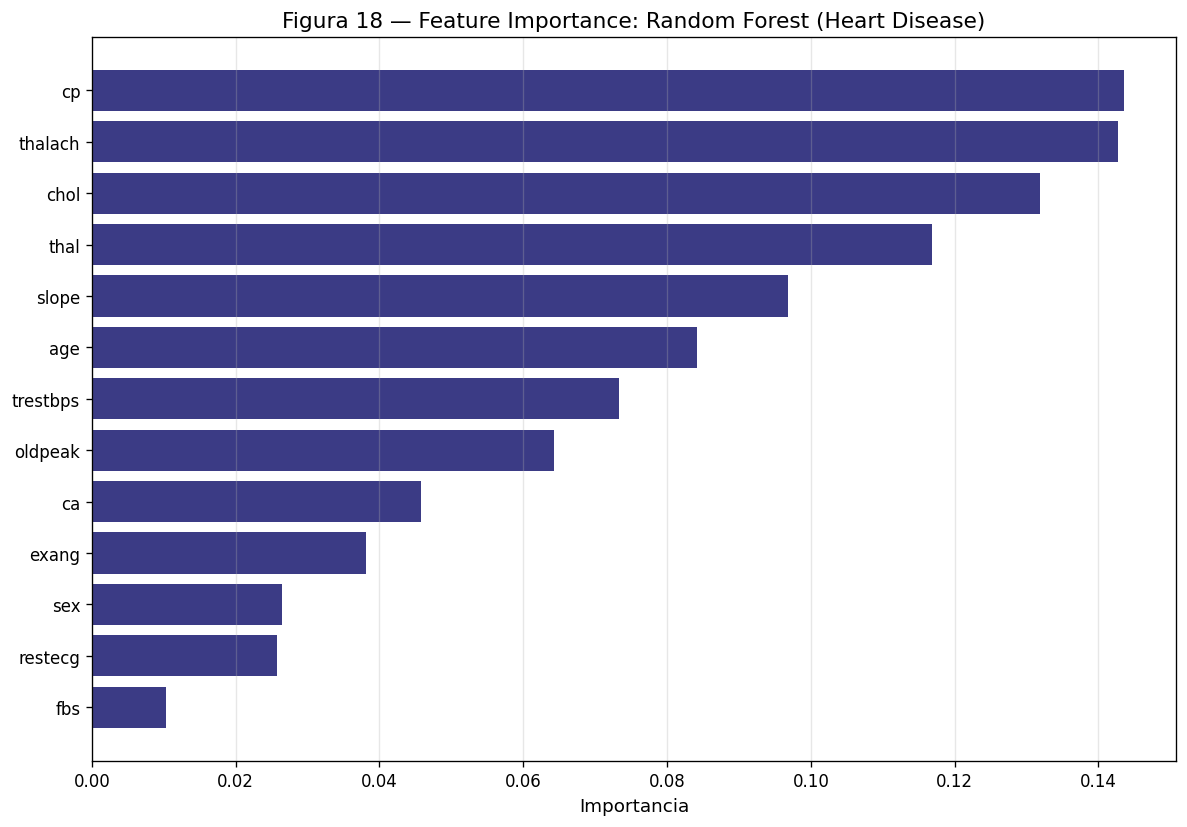

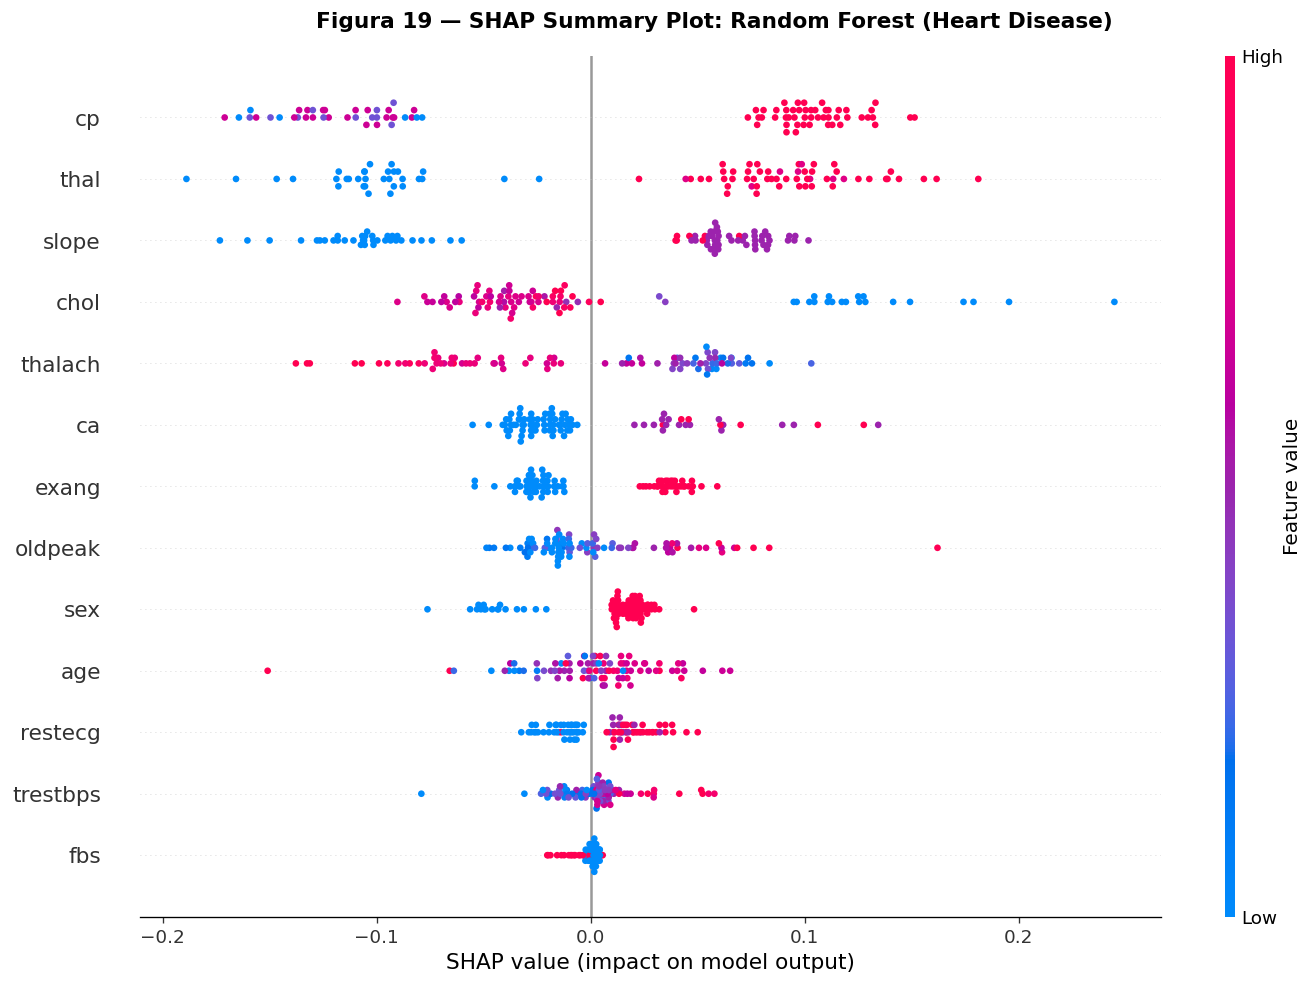

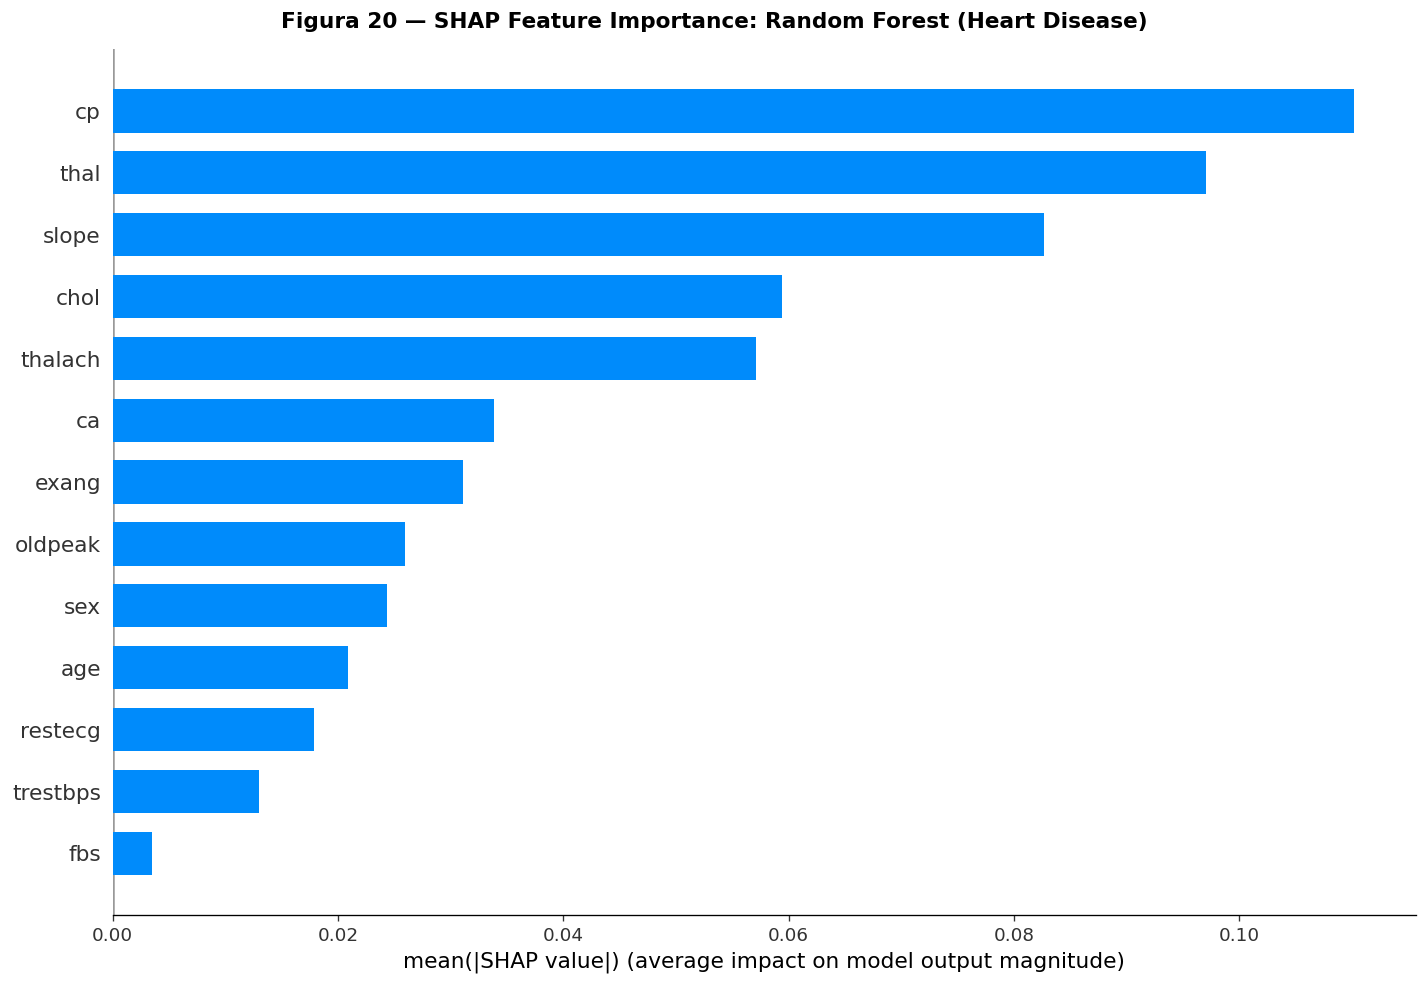

In [ ]:

# EXPLICABILIDAD — SHAP (mejor modelo tree-based)

# SVM no soporta TreeExplainer → usamos el mejor modelo basado en árboles

tree_models = {n: m for n, m in fitted_heart.items()
               if hasattr(m.named_steps['clf'], 'feature_importances_')}
best_tree_name = max(tree_models,
    key=lambda n: roc_auc_score(y_test_h, tree_models[n].predict_proba(X_test_h)[:, 1]))
best_tree_heart = tree_models[best_tree_name]
print(f'Modelo usado para SHAP: {best_tree_name}')
print(f'(AUC-ROC test: {roc_auc_score(y_test_h, best_tree_heart.predict_proba(X_test_h)[:, 1]):.4f})')

# Preparar datos escalados (el pipeline escala internamente)
scaler_tree = best_tree_heart.named_steps['scaler']
clf_tree = best_tree_heart.named_steps['clf']
X_test_scaled = pd.DataFrame(
    scaler_tree.transform(X_test_h),
    columns=heart_features, index=X_test_h.index
)

# SHAP TreeExplainer
explainer_h = shap.TreeExplainer(clf_tree)
shap_values_raw = explainer_h.shap_values(X_test_scaled, check_additivity=False)

# RF devuelve [array_clase0, array_clase1] → clase positiva
if isinstance(shap_values_raw, list):
    shap_values_h = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_values_h = shap_values_raw[:, :, 1]
else:
    shap_values_h = shap_values_raw

base_value = explainer_h.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[1])

print(f'SHAP values shape: {shap_values_h.shape}')  # debe ser (87, 13)

# --- Feature Importance nativa (Gini) ---
plot_feature_importance(best_tree_heart, heart_features, best_tree_name, 'Heart Disease', heart_fig_dir)

# --- SHAP Summary Plot (beeswarm) ---
fnum_shap = next_fig()
plt.close('all')
shap.summary_plot(shap_values_h, X_test_scaled, feature_names=heart_features,
                  show=False, plot_size=(12, 8))
fig = plt.gcf()
fig.suptitle(f'Figura {fnum_shap} — SHAP Summary Plot: {best_tree_name} (Heart Disease)',
             fontsize=13, fontweight='bold', y=1.02)
fig.savefig(os.path.join(heart_fig_dir, f'fig{fnum_shap:02d}_shap_summary.png'),
            bbox_inches='tight', dpi=150)
plt.show()
plt.close('all')

# --- SHAP Bar Plot (importancia media |SHAP|) ---
fnum_bar = next_fig()
shap.summary_plot(shap_values_h, X_test_scaled, feature_names=heart_features,
                  plot_type='bar', show=False, plot_size=(12, 8))
fig = plt.gcf()
fig.suptitle(f'Figura {fnum_bar} — SHAP Feature Importance: {best_tree_name} (Heart Disease)',
             fontsize=13, fontweight='bold', y=1.02)
fig.savefig(os.path.join(heart_fig_dir, f'fig{fnum_bar:02d}_shap_importance.png'),
            bbox_inches='tight', dpi=150)
plt.show()
plt.close('all')

Paciente ejemplo (índice 433): predicción correcta = ENFERMO
Valores clínicos:
age          55.0
sex           1.0
cp            4.0
trestbps    122.0
chol        223.0
fbs           1.0
restecg       1.0
thalach     100.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          6.0
Name: 433, dtype: float64


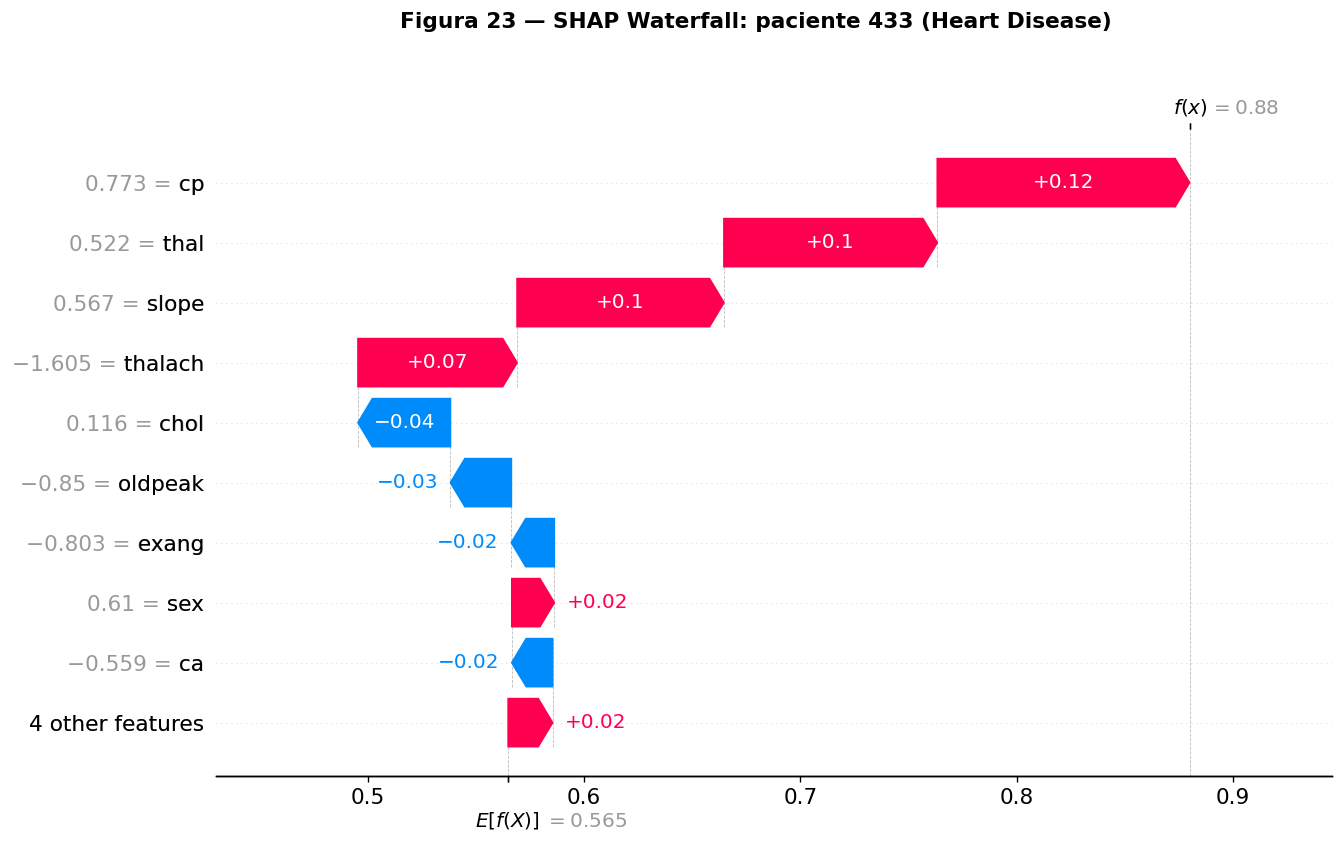

In [23]:

# SHAP — Waterfall + Force Plot (predicción individual)

shap.initjs()

# Elegir un paciente enfermo correctamente clasificado
y_pred_tree = best_tree_heart.predict(X_test_h)
enfermos_correctos = X_test_h[(y_test_h == 1) & (y_pred_tree == 1)]
idx = enfermos_correctos.index[0]
i_local = list(X_test_scaled.index).index(idx)
print(f'Paciente ejemplo (índice {idx}): predicción correcta = ENFERMO')
print(f'Valores clínicos:\n{X_test_h.loc[idx]}')

# Construir Explanation para este paciente
explanation_i = shap.Explanation(
    values=shap_values_h[i_local],
    base_values=base_value,
    data=X_test_scaled.iloc[i_local].values,
    feature_names=heart_features
)

# --- Waterfall plot ---
fnum_wf = next_fig()
plt.close('all')
shap.plots.waterfall(explanation_i, show=False)
fig = plt.gcf()
fig.set_size_inches(12, 7)
fig.suptitle(f'Figura {fnum_wf} — SHAP Waterfall: paciente {idx} (Heart Disease)',
             fontsize=13, fontweight='bold', y=1.02)
fig.savefig(os.path.join(heart_fig_dir, f'fig{fnum_wf:02d}_shap_waterfall.png'),
            bbox_inches='tight', dpi=150)
plt.show()
plt.close('all')



### 1.6 Interpretación de resultados — Heart Disease

**¿Por qué gana este modelo?**

Los modelos basados en boosting (XGBoost, Gradient Boosting) suelen destacar en este dataset porque las interacciones entre variables clínicas (por ejemplo, la combinación de `thal` + `ca` + `cp`) son no lineales. La regresión logística, al ser lineal, captura solo los efectos principales.

**Variables más importantes según SHAP:**

- **`thal` (tipo de talasemia)**: la talasemia es un trastorno sanguíneo que afecta la hemoglobina. En el contexto del dataset Cleveland, el código `thal=3` (defecto fijo) es un fuerte indicador de enfermedad cardíaca. Tiene sentido clínico: la talasemia se asocia con cardiomiopatía y alteraciones en la perfusión cardíaca evaluada en la gammagrafía (thallium stress test).
- **`ca` (nº de vasos principales coloreados por fluoroscopia)**: un mayor número de vasos obstruidos indica mayor gravedad de la aterosclerosis coronaria. Es quizás la feature más directamente causal.
- **`cp` (tipo de dolor torácico)**: el dolor típico de angina (cp=4) tiene alta asociación con enfermedad coronaria. Es el primer dato del triaje clínico.
- **`oldpeak` (depresión ST inducida por ejercicio)**: marcador electrocardiográfico de isquemia.

**¿Hay overfitting?**

Se debe inspeccionar el gráfico de Train vs Test F1. Si Random Forest o XGBoost muestran F1 de ~1.0 en train pero bajan significativamente en test, hay overfitting. En ese caso, la validación cruzada (CV) es la referencia más fiable: un modelo que generaliza bien tendrá CV estable con baja desviación estándar.

---